In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
plt.rcParams['figure.figsize'] = (8, 5)
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("data/hr_data.csv")
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [3]:
df = df[[
        'Age',
        'Attrition',
        'Department',
        'JobRole',
        'Gender',
        'MonthlyIncome',
        'YearsAtCompany',
        'OverTime',
        'JobSatisfaction',
        'WorkLifeBalance'
    ]]
df.head()

,Age,Attrition,Department,JobRole,Gender,MonthlyIncome,YearsAtCompany,OverTime,JobSatisfaction,WorkLifeBalance
0,41,Yes,Sales,Sales Executive,Female,5993,6,Yes,4,1
1,49,No,Research & Development,Research Scientist,Male,5130,10,No,2,3
2,37,Yes,Research & Development,Laboratory Technician,Male,2090,0,Yes,3,3
3,33,No,Research & Development,Research Scientist,Female,2909,8,Yes,3,3
4,27,No,Research & Development,Laboratory Technician,Male,3468,2,No,2,3


In [4]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
#“I converted the Attrition column into numerical form so that it could be easily analyzed and aggregated, where 1 represents employees who left and 0 represents employees who stayed.”
df['Attrition'].value_counts(normalize=True) * 100
#“This step calculates the percentage of employees who left versus those who stayed, giving a high-level understanding of how serious the attrition problem is.”

Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64

In [5]:
df.groupby('Department')['Attrition'].mean() * 100
#“Here, I analyzed attrition rates department-wise to identify which departments experience higher employee turnover.”

Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: Attrition, dtype: float64

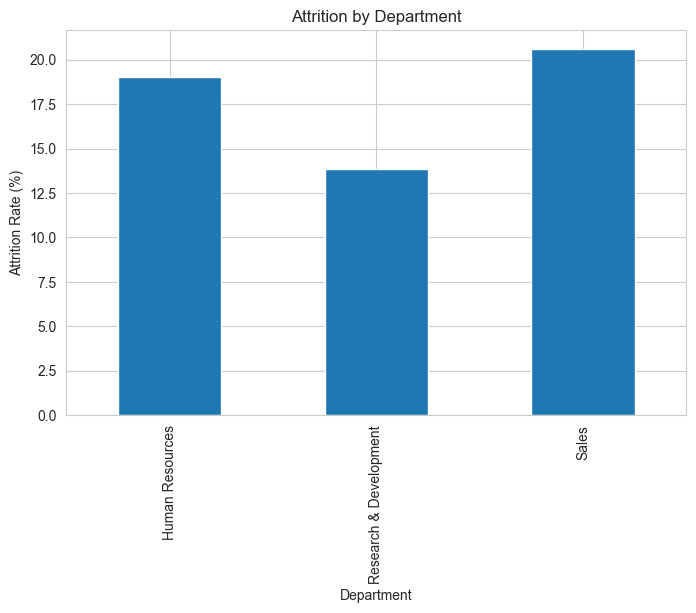

In [6]:
(df.groupby('Department')['Attrition'].mean() * 100).plot(kind='bar')
plt.ylabel("Attrition Rate (%)")
plt.title("Attrition by Department")
plt.show()
#“This bar chart visually highlights differences in attrition across departments, making it easier to identify departments that may need focused retention strategies.”

In [7]:
df.groupby('OverTime')['Attrition'].mean() * 100
#I compared attrition rates between employees who work overtime and those who do not, to assess whether workload contributes to employees leaving the company.

OverTime
No     10.436433
Yes    30.528846
Name: Attrition, dtype: float64

In [8]:
df.groupby('Attrition')['MonthlyIncome'].mean()
#This analysis compares average monthly income of employees who left versus those who stayed, helping evaluate whether compensation plays a role in attrition.

Attrition
0    6832.739659
1    4787.092827
Name: MonthlyIncome, dtype: float64

In [9]:
df.groupby('Attrition')['YearsAtCompany'].mean()
#This step examines whether employees with less experience are more likely to leave, which helps identify early-stage retention risks.

Attrition
0    7.369019
1    5.130802
Name: YearsAtCompany, dtype: float64

In [10]:
df.groupby('Attrition')[['JobSatisfaction', 'WorkLifeBalance']].mean()
#Finally, I analyzed job satisfaction and work-life balance scores to understand how employee well-being impacts attrition.

,JobSatisfaction,WorkLifeBalance
Attrition,,
0,2.778589,2.781022
1,2.468354,2.658228


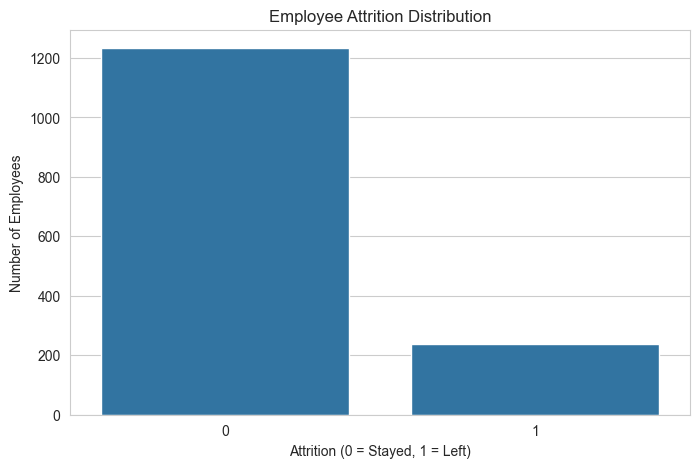

In [11]:
sns.countplot(x='Attrition', data=df)
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Number of Employees")
plt.show()

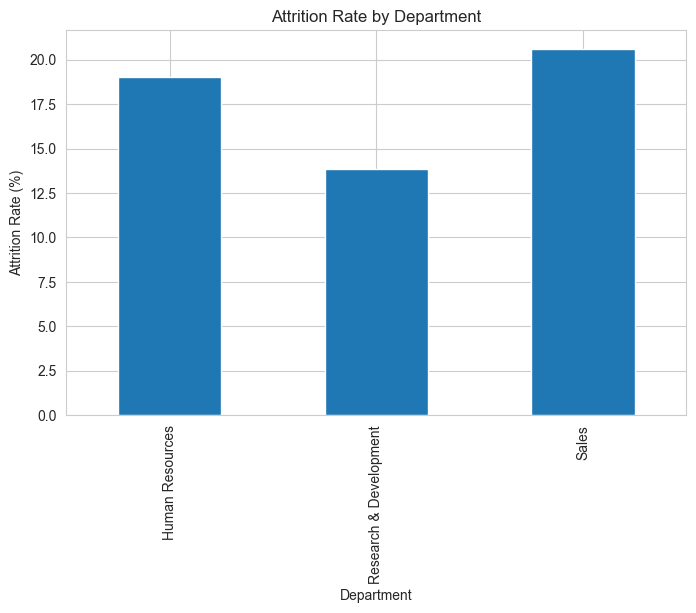

In [12]:
dept_attrition = df.groupby('Department')['Attrition'].mean() * 100
dept_attrition.plot(kind='bar')
plt.ylabel("Attrition Rate (%)")
plt.title("Attrition Rate by Department")
plt.show()

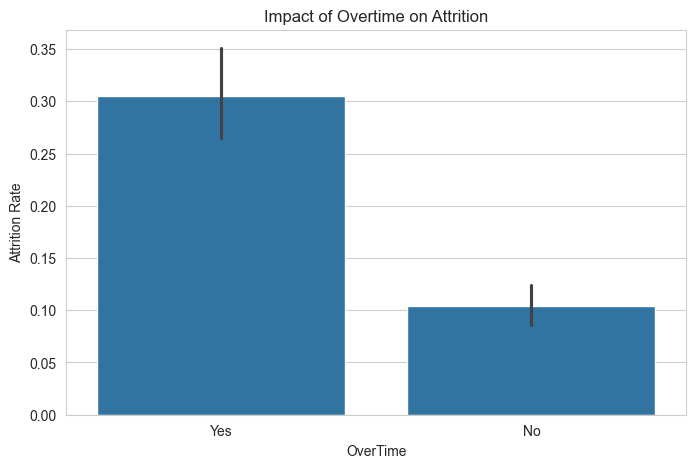

In [13]:
sns.barplot(x='OverTime', y='Attrition', data=df, estimator=np.mean)
plt.ylabel("Attrition Rate")
plt.title("Impact of Overtime on Attrition")
plt.show()